In [1]:
"""
Automatically reloads libraries and utilities every time a cell is run
"""
%load_ext autoreload
%autoreload 2

In [23]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from utils.PSF_helpers import *
from utils.Plot_helpers import *
from utils.Zernike_helpers import *
from utils.Booth_helpers import *

import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

In [24]:
from scipy.fft import fft2
from scipy.fft import ifft2
from scipy.fft import fftshift
from scipy.fft import ifftshift

In [25]:
#minor style things to make the figures look nice
plt.style.use("bmh")
plt.rcParams["figure.figsize"] = [548 / 72, 390 / 72]
plt.rcParams["font.size"] = 12
plt.rcParams['text.usetex'] = True
plt.rcParams["figure.dpi"] = 300
import os
os.environ["PATH"] += os.pathsep + "/Library/TeX/texbin"

In [26]:
N_order = 3                # 3 for 3P, 2 for 2P
lambd = 1.3e-3             # Wavelength [mm]
n = 1.333                  # Refractive index
k = 2*n*np.pi/lambd        # Wavenumber
num_apt = 1.05            # Numerical aperture
f = 7.2                    # Focal length of objective (Olympus) [mm]
mag = 4                    # Magnification rate from input to objective
w_0 = 3.5                  # mm

alpha = np.arcsin(num_apt / n)

L_ffp = 0.04
grid_ffp = 256
grid = Centered_Square_Grid(L_ffp, grid_ffp, 0)
#CONJUGATE BFP LENGTH
grid_bfp = grid_ffp
L_bfp = (lambd * f * grid_bfp) / L_ffp
microscope = Microscope(N_order, lambd, n, num_apt, f, mag, w_0, L_bfp, grid_bfp)
x, y = grid.get_xy()

h_power = 2 * N_order

FIXED_GAMMA = 1e-20

In [27]:
def forward_H(microscope, aberration):
    H = microscope.compute_pupil_function(aberration, gaussian = True) 
    return H

def forward_h(microscope, aberration):
    H = forward_H(microscope, aberration)
    h = ifft2(H, workers = -1)
    return h

def forward_PSF(microscope, aberration):
    h = forward_h(microscope, aberration)
    PSF = np.abs(h)**h_power
    return fftshift(PSF)

def circular_convolve(f, s_centered):
    S = fft2(ifftshift(s_centered))
    F = fft2(f, workers = -1)
    return np.real(ifft2(S * F, workers = -1))

def forward_image(microscope, f, aberration):
    PSF = forward_PSF(microscope, aberration)
    return circular_convolve(f, PSF)

def get_diversity_image(microscope, f, true_aberration, diversity_aberration):
    return forward_image(microscope, f, true_aberration + diversity_aberration)

In [28]:
def objective(microscope, d_stack, a_proposed, a_stack, gamma=1e-6):
    H_stack = [forward_H(microscope, a + a_proposed) for a in a_stack]
    h_stack = [ifft2(H, workers = -1) for H in H_stack]
    s_stack = [np.abs(h)**h_power for h in h_stack]

    S_stack = np.stack([fft2(s, workers = -1) for s in s_stack], axis=0)
    D_stack = np.stack([fft2(d, workers = -1) for d in d_stack], axis=0)

    first_term = np.sum(np.abs(D_stack)**2)

    numerator = np.abs(np.sum(np.conj(S_stack) * D_stack, axis=0))**2
    denominator = gamma + np.sum(np.abs(S_stack)**2, axis=0)

    return np.real(first_term - np.sum(numerator / denominator))

In [29]:
#grid = grid along which the images were taken
#d_stack = list of phase diverse images
#a_stack = list of aberrations applied along each phase diverse image
#aberration_guesss = guess for the inherent sample aberration
#gamma = regularization parameters
def estimate_object(microscope,
                    d_stack,
                    a_stack,
                    aberration_guess = EmptyAberration(),
                    gamma = FIXED_GAMMA):
    N = len(d_stack)
    #get the pupil functions
    H_stack = [forward_H(microscope, a + aberration_guess) for a in a_stack]
    #get the iffts 
    h_stack = [ifft2(H, workers = -1) for H in H_stack]
    #get the stack of PSFS
    s_stack = [np.abs(h)**h_power for h in h_stack]
    #normalize the PSFs
    #take fourier transforms
    S_stack = [fft2(s, workers = -1) for s in s_stack]
    D_stack = [fft2(d, workers = -1) for d in d_stack]
    #compute the estimator
    numerator = np.sum([np.conj(S_stack[j]) * D_stack[j] for j in range(N)], axis = 0)
    denominator = gamma + np.sum([np.abs(S_stack[j])**2 for j in range(N)], axis = 0 )
    F = numerator/denominator 
    f = ifft2(F)
    return np.real(f), F


In [30]:
#grid = grid along which the images were taken
#d_stack = list of phase diverse images
#a_stack = list of aberrations applied along each phase diverse image
#aberration_guesss = guess for the inherent sample aberration
#modes_corrected = list of modes to correct along
#gamma = regularization parameters
def estimate_aberration_gradient(microscope,
                    d_stack,
                    a_stack,
                    F_guess,
                    modes_corrected,
                    aberration_guess = EmptyAberration()):
    N = len(d_stack)
    
    D_stack = [fft2(d) for d in d_stack]

    #get the pupil functions
    H_stack = [forward_H(microscope, a + aberration_guess) for a in a_stack]
    #get the iffts 
    h_stack = [ifft2(H, workers = -1) for H in H_stack]
    #get the stack of PSFS
    s_stack = [np.abs(h)**h_power for h in h_stack]
    #normalize the PSFs
    #take fourier transforms
    S_stack = [fft2(s, workers = -1) for s in s_stack]

    V_stack = [np.conj(F_guess) * D_stack[i] - np.abs(F_guess)**2 * S_stack[i] for i in range(N)]

    inner_product = [np.abs(h_stack[i])**(h_power - 2) * h_stack[i] *  np.real(ifft2(V_stack[i], workers = -1)) for i in range(N)]

    g_stack = [np.imag(np.conj(H_stack[i]) * fft2(inner_product[i], workers = -1)) for i in range(N) ] 
    g = -2 * N_order * np.sum(g_stack, axis = 0) 
    Z_stack = [microscope.compute_phase_map(Aberration([m], [1.0])) for m in modes_corrected]
    #get the component along each zernike
    g_c = np.array([np.sum(g * Z) for Z in Z_stack])
    return g, g_c




In [31]:
def get_Q(h_stack,
          gamma):
    s_stack = [np.abs(h)**h_power for h in h_stack]
    #normalize the PSFs
    #take fourier transforms
    S_squared_stack = [np.abs(fft2(s, workers = -1))**2 for s in s_stack]

    return gamma + np.sum(S_squared_stack, axis = 0)

#indexed by j and k
def get_U_tilde(D_tilde_stack,
                   h_stack,
                   H_stack,
                   Z_n):
    
    N = len(D_tilde_stack)
    L = len(Z_n)

    #precompute U_tilde_jk terms
    inner_stack = [ifft2(H * Z_n, workers = -1) for H in H_stack]
    fourier_stack = [fft2(np.imag(np.abs(h_stack[i])**(h_power - 2) * np.conj(h_stack[i]) * inner_stack[i]), workers = -1) for i in range (N)]

    U_tilde = np.zeros((N, N, L, L), dtype=complex)
    for j in range(N):
        for k in range(N):
            U_tilde[j,k] = D_tilde_stack[j] * fourier_stack[k] - D_tilde_stack[k] * fourier_stack[j]

    return U_tilde

def get_H_gn_phi_n(Z_n,
                   h_stack,
                   H_stack,
                   D_tilde_stack,
                   U_tilde):
    
    L = len(Z_n)
    N = len(D_tilde_stack)
    
    total = np.zeros((L, L))
    for k in range(N):
        for j in range(k):

            inner_term_1 = np.abs(h_stack[j])**(h_power - 2) * h_stack[j] * ifft2(np.conj(D_tilde_stack[k]) * U_tilde[j,k], workers = -1)
            term_1 = np.conj(H_stack[j]) * fft2(inner_term_1, workers = -1)

            inner_term_2 = np.abs(h_stack[k])**(h_power - 2) * h_stack[k] * ifft2(np.conj(D_tilde_stack[j]) * U_tilde[j,k], workers = -1)
            term_2 = np.conj(H_stack[k]) * fft2(inner_term_2, workers = -1)

            total += np.imag(term_1 - term_2)

    return 4 * N_order**2 * total


def get_hessian(microscope,
                d_stack,
                a_stack,
                aberration_guess,
                modes_corrected,
                gamma = FIXED_GAMMA):
    


    n_modes = len(modes_corrected)
    hessian = np.zeros((n_modes, n_modes))

    #fourier trasnform the images
    D_stack = np.array([fft2(d, workers = -1) for d in d_stack])
    #get the pupil functions
    H_stack = [forward_H(microscope, a + aberration_guess) for a in a_stack]
    #get the iffts 
    h_stack = [ifft2(H, workers = -1) for H in H_stack]
    #get Q
    Q = get_Q(h_stack, gamma)
    #compute D_tildes
    D_tilde_stack = D_stack/np.sqrt(Q)
    Z_stack = [microscope.compute_phase_map(Aberration([m], [1.0])) for m in modes_corrected]
    U_tilde_stack = [get_U_tilde(D_tilde_stack, h_stack, H_stack, Z) for Z in Z_stack]

    H_gn_phi_ns = [get_H_gn_phi_n(Z_stack[i],
                                h_stack,
                                H_stack,
                                D_tilde_stack,
                                U_tilde_stack[i])
                                for i in range(n_modes)]

    for m in range(n_modes):
        Z_m = Z_stack[m]
        for n in range(m + 1):
            hessian_element = np.sum(H_gn_phi_ns[n] * Z_m)
            hessian[m,n] = hessian_element
            hessian[n,m] = hessian_element
            
    return hessian

In [32]:
import time 
def loop_optimize(n_loops,
                  microscope,
                  d_stack,
                  a_stack,
                  modes_corrected):
    rate = 1
    #initialize variables as necessary
    a_guess = EmptyAberration()
    F_guess = 0
    c_guess = 0

    for i in range(1, n_loops + 1):

        t = time.time()
        f_guess, F_guess = estimate_object(microscope, d_stack, a_stack, a_guess)
        s = time.time()
        print(f"\t Estimated object in {np.round(s-t, 3)} seconds")

        t = time.time()
        g, g_c = estimate_aberration_gradient(microscope, d_stack, a_stack, F_guess, modes_corrected, a_guess)
        s = time.time()
        print(f"\t Estimated gradient in {np.round(s-t, 3)} seconds")

        t = time.time()
        hessian = get_hessian(microscope, d_stack, a_stack, a_guess, modes_corrected)
        s = time.time()
        print(f"\t Estimated Hessian in {np.round(s-t, 3)} seconds")

        c_guess = c_guess -1 * np.matmul(np.linalg.inv(hessian), g_c) * rate
        a_guess = Aberration(modes_corrected, c_guess)

        J = objective(microscope, d_stack, a_guess, a_stack)
        print(f"Loop {i}: J = {np.round(J * 1e13, 4)}")
        print(c_guess)

    return c_guess, F_guess




In [106]:
from PIL import Image 
f = np.mean(np.array(Image.open("onion.png")), axis = 2)
#normalize
f = (f - np.min(f)) / (np.max(f) - np.min(f))
#clip
thresh = 0.7
f[f>thresh] = 1
f[f<=thresh] = 0

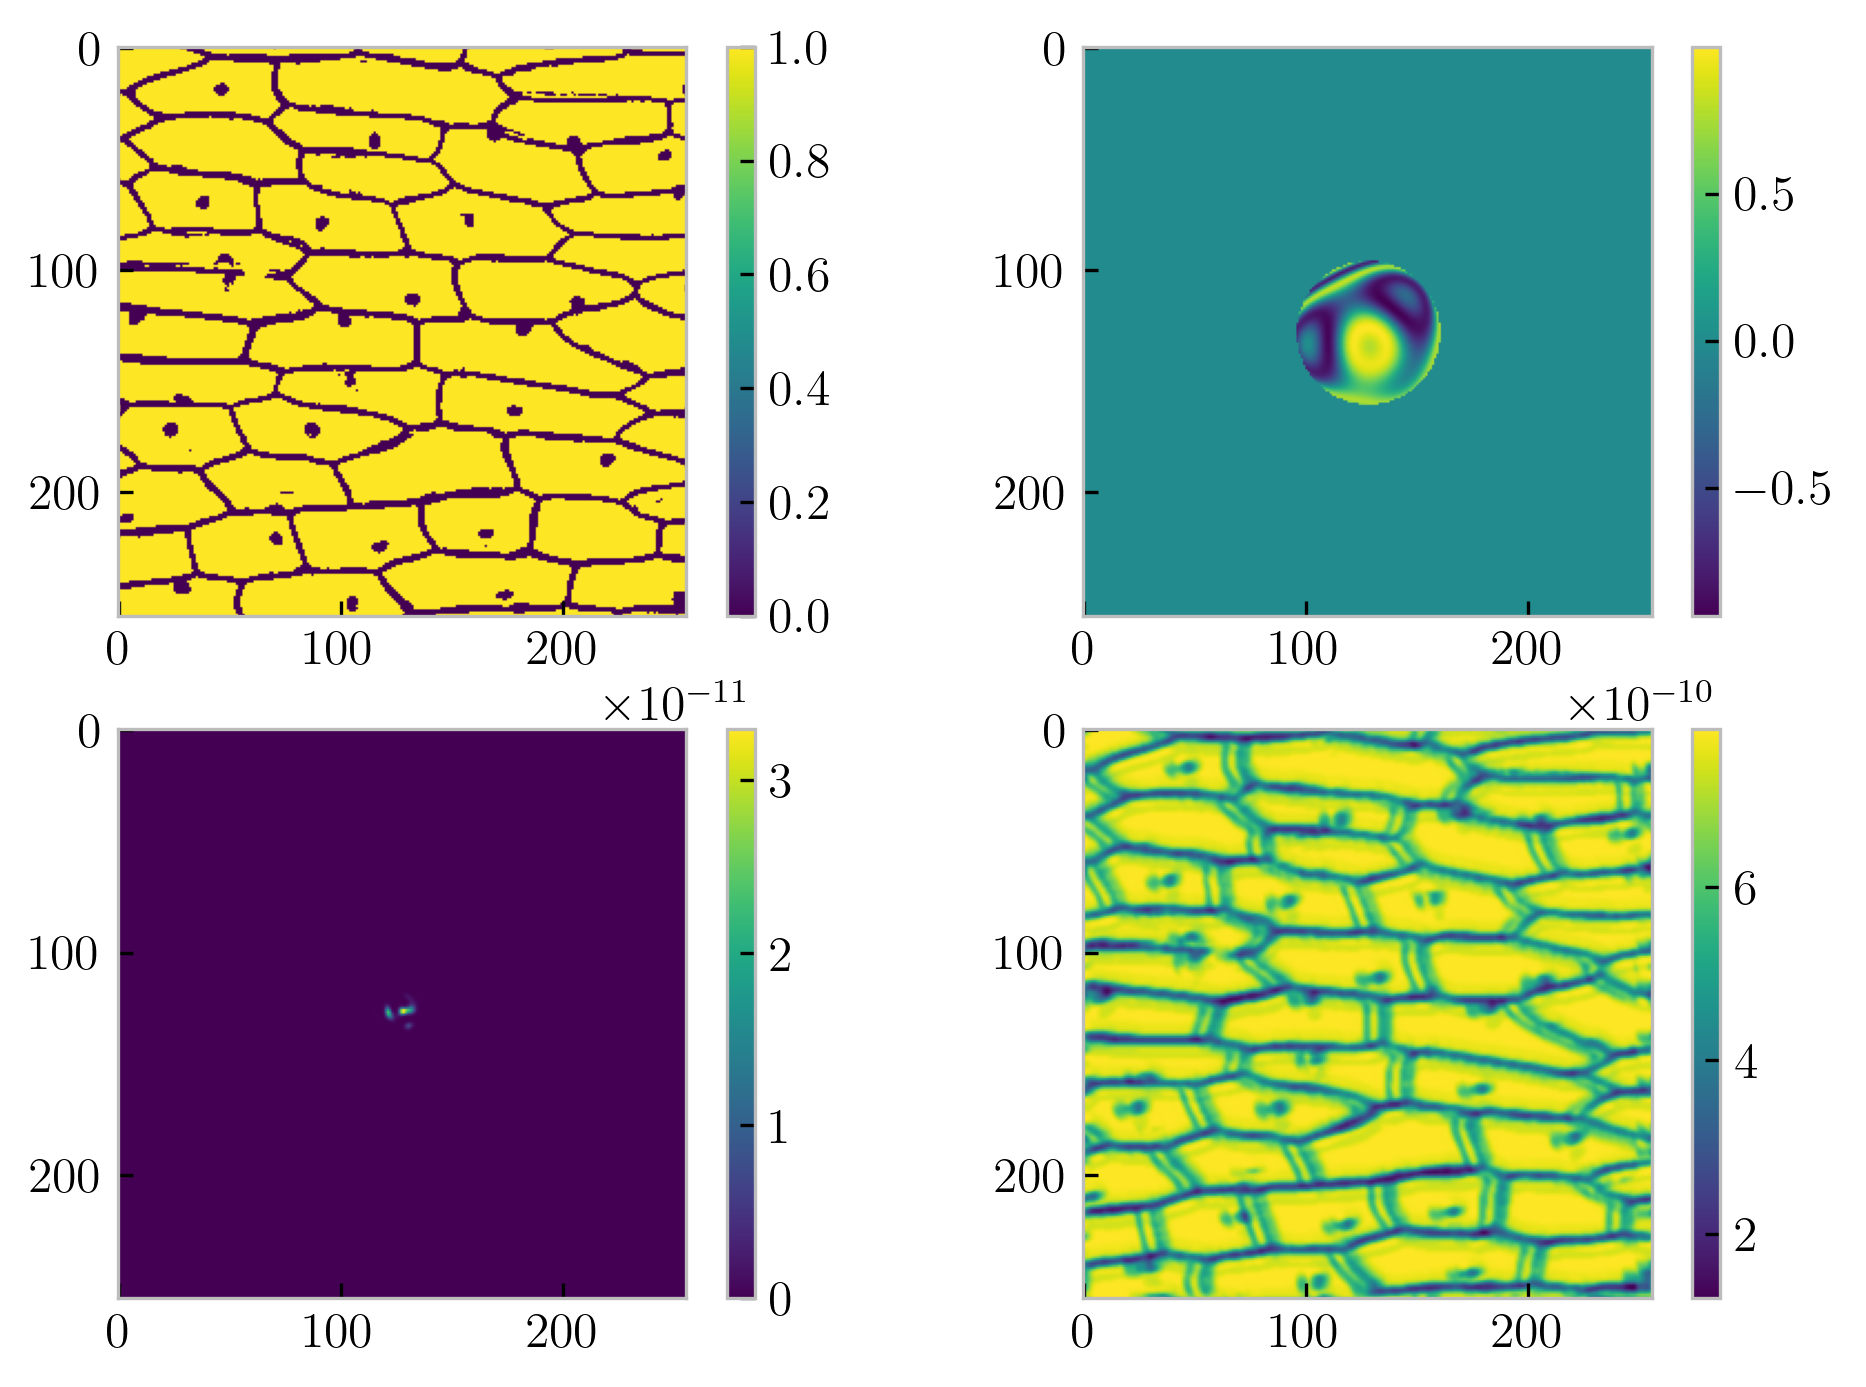

In [107]:
#x, y, f = random_bead_img(grid, 10, 0.002)
true_modes = [[0, 4], [-3, 3], [-2,2], [1, 3], [2,2]]
true_c = [0.3, -0.3,0.3,-0.3,0.3]
true_aberration = Aberration(true_modes, true_c)
H = forward_H(microscope, true_aberration)
PSF = forward_PSF(microscope, true_aberration)
#plot_intensity(x, y, PSF, normalize = False)
d = forward_image(microscope, f, true_aberration)
#plot_intensity(x, y, d, normalize = False)

fig, axs = plt.subplots(2, 2)
axs = axs.flatten()

im0 = axs[0].imshow(f)
axs[0].grid(False)

im1 = axs[1].imshow(np.imag(H))
axs[1].grid(False)

im2 = axs[2].imshow(PSF)
axs[2].grid(False)

im3= axs[3].imshow(d)
axs[3].grid(False)

fig.colorbar(im0, ax = axs[0])
fig.colorbar(im1, ax = axs[1])
fig.colorbar(im2, ax = axs[2])
fig.colorbar(im3, ax = axs[3])

[]

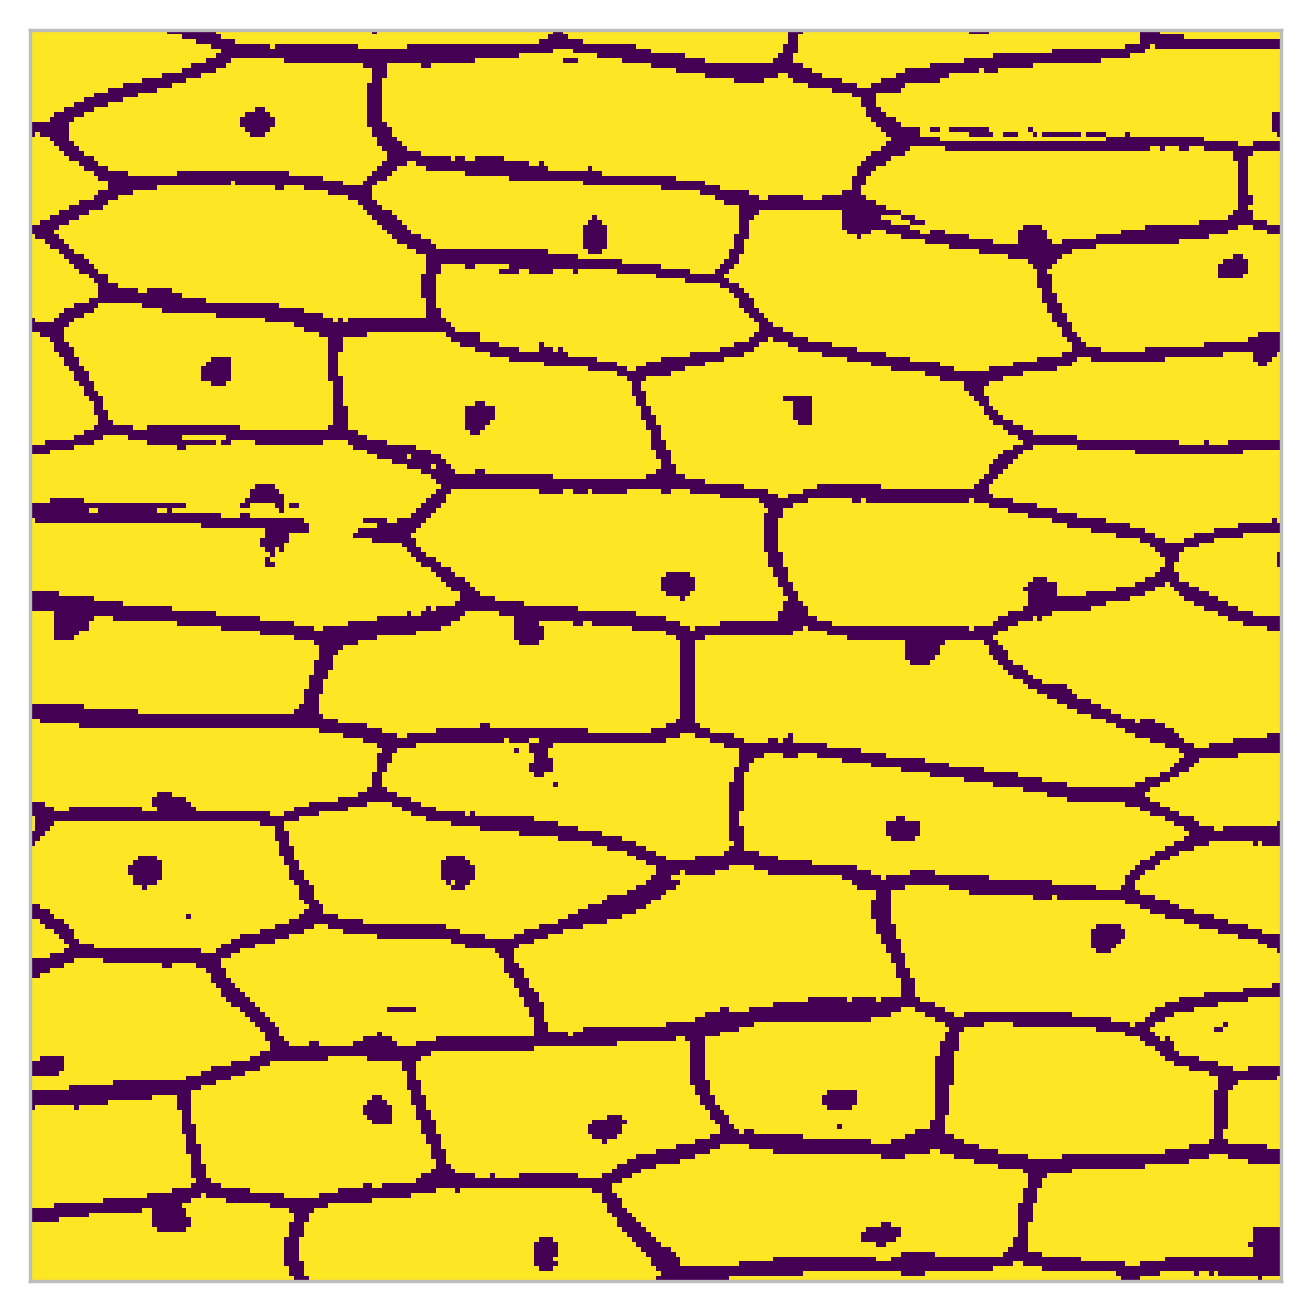

In [108]:
H = forward_H(microscope, true_aberration)
fig, ax = plt.subplots()
ax.imshow(f, cmap = "viridis")
ax.grid(False)
ax.set_xticks([])
ax.set_yticks([])

In [109]:
bias_modes = [
    [-2, 2], [0, 2], [2, 2],
    [-3, 3], [-1, 3], [1, 3], [3, 3],
    [-4, 4], [-2, 4], [0, 4], [2, 4], [4, 4]]
#bias_modes= true_modes

a_stack = [
    EmptyAberration(),
]

bias_image_stack = [Aberration([m], [0.3]) for m in bias_modes]
a_stack = np.concatenate([a_stack, bias_image_stack])
d_stack = np.array([get_diversity_image(microscope, f, true_aberration, a) for a in a_stack])

modes_corrected = true_modes

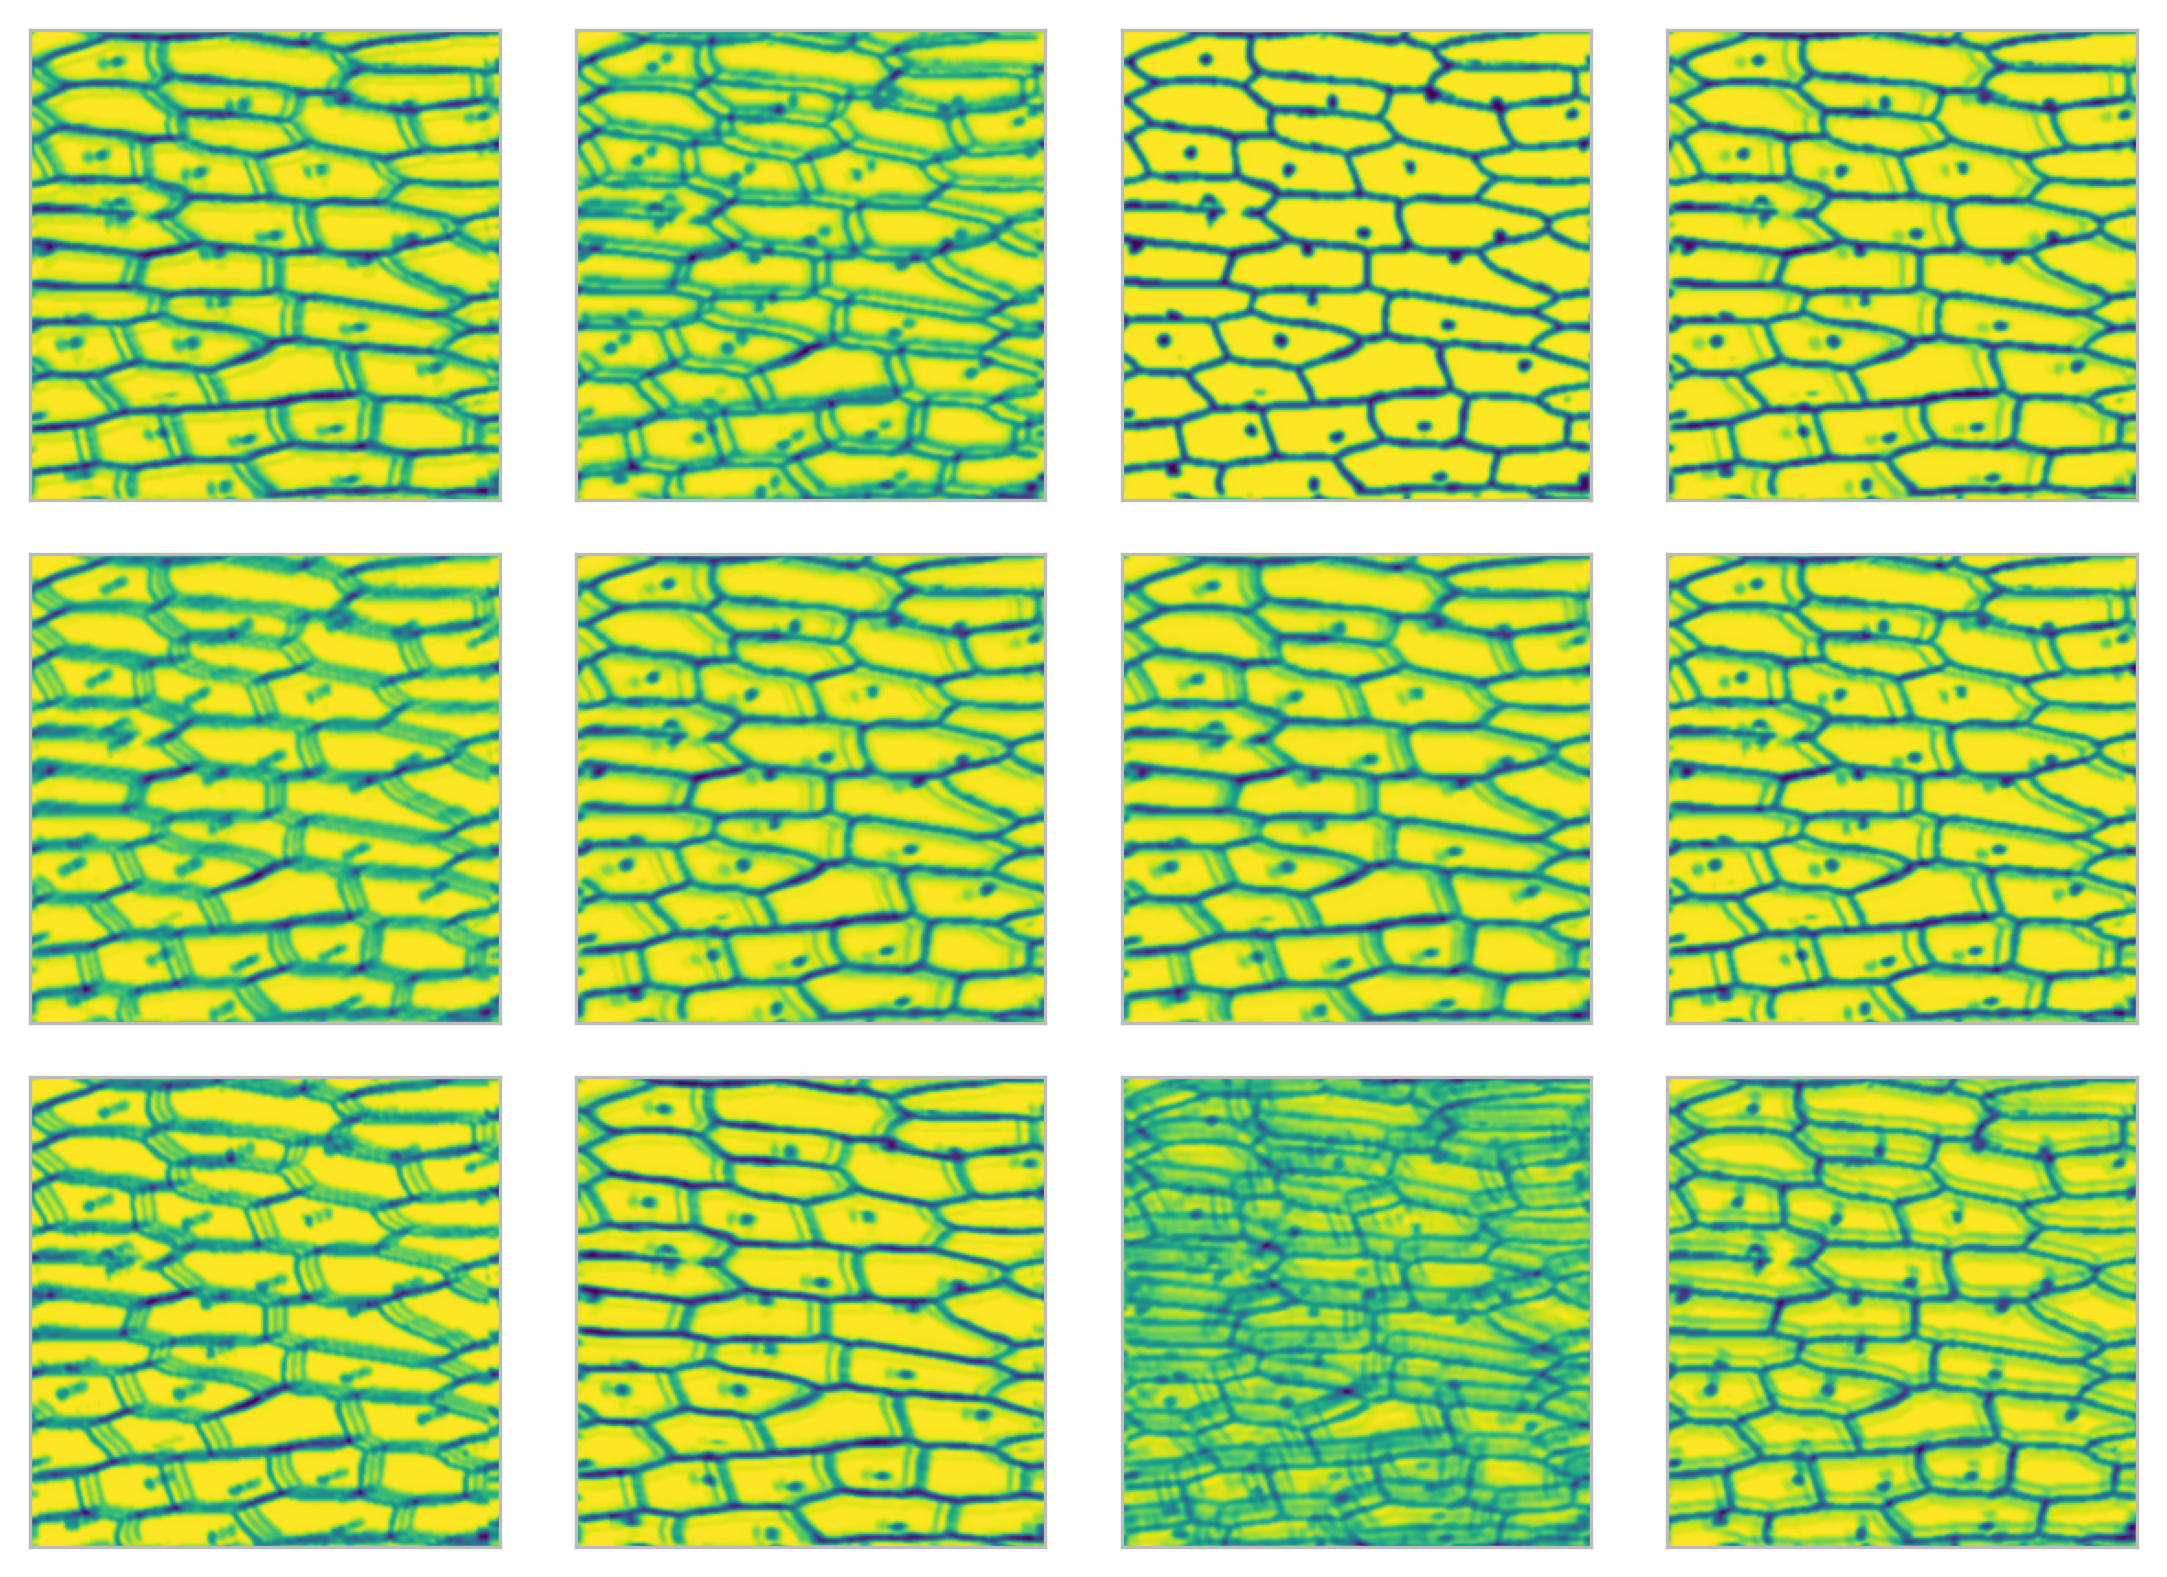

In [110]:
a = 3
b = 4
fig, axs = plt.subplots(a, b, layout = "tight")
axs = axs.flatten()
for i in range(a*b):
    axs[i].imshow(d_stack[i])
    axs[i].grid(False)
    axs[i].set_xticks([])
    axs[i].set_yticks([])

In [111]:
c_guess, F_guess = loop_optimize(25,
              microscope,
                  d_stack,
                  a_stack,
                  modes_corrected)

	 Estimated object in 0.102 seconds
	 Estimated gradient in 0.127 seconds
	 Estimated Hessian in 3.339 seconds
Loop 1: J = 325630.1277
[ 0.05027947 -0.04733391 -0.00773686 -0.04202306 -0.07115595]
	 Estimated object in 0.076 seconds
	 Estimated gradient in 0.125 seconds
	 Estimated Hessian in 2.472 seconds
Loop 2: J = 325630.1278
[ 0.06755984 -0.06335526 -0.01035684 -0.05949846 -0.08449198]
	 Estimated object in 0.078 seconds
	 Estimated gradient in 0.122 seconds
	 Estimated Hessian in 2.504 seconds
Loop 3: J = 325630.1279
[ 0.08650811 -0.07063921 -0.00925027 -0.06862531 -0.09061085]
	 Estimated object in 0.083 seconds
	 Estimated gradient in 0.135 seconds
	 Estimated Hessian in 2.463 seconds
Loop 4: J = 325630.1279
[ 0.10396939 -0.07495255 -0.00656879 -0.07535382 -0.09377982]
	 Estimated object in 0.096 seconds
	 Estimated gradient in 0.144 seconds
	 Estimated Hessian in 3.24 seconds
Loop 5: J = 325630.128
[ 0.1201463  -0.07818769 -0.00265126 -0.08122225 -0.0953766 ]
	 Estimated objec

[]

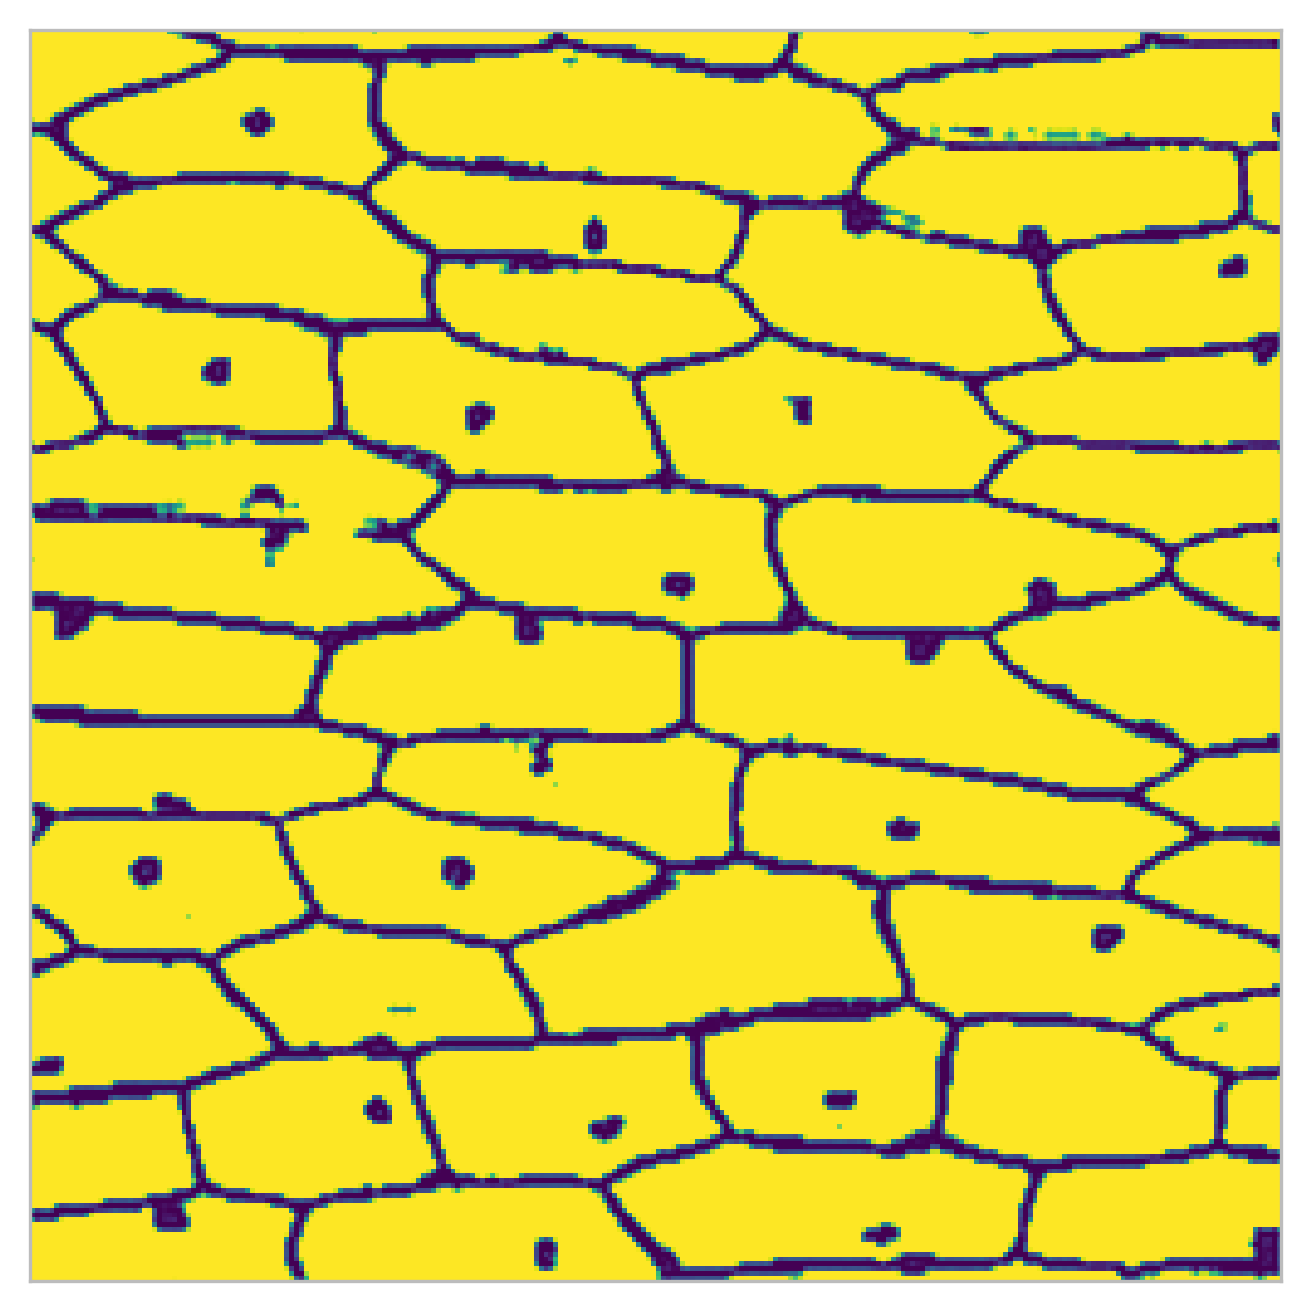

In [114]:
fig, ax = plt.subplots()
img_guess = np.real(ifft2(F_guess))
img_guess = np.clip(img_guess, 0, np.inf)
ax.imshow(img_guess, vmax = thresh)
ax.grid(False)
ax.set_xticks([])
ax.set_yticks([])

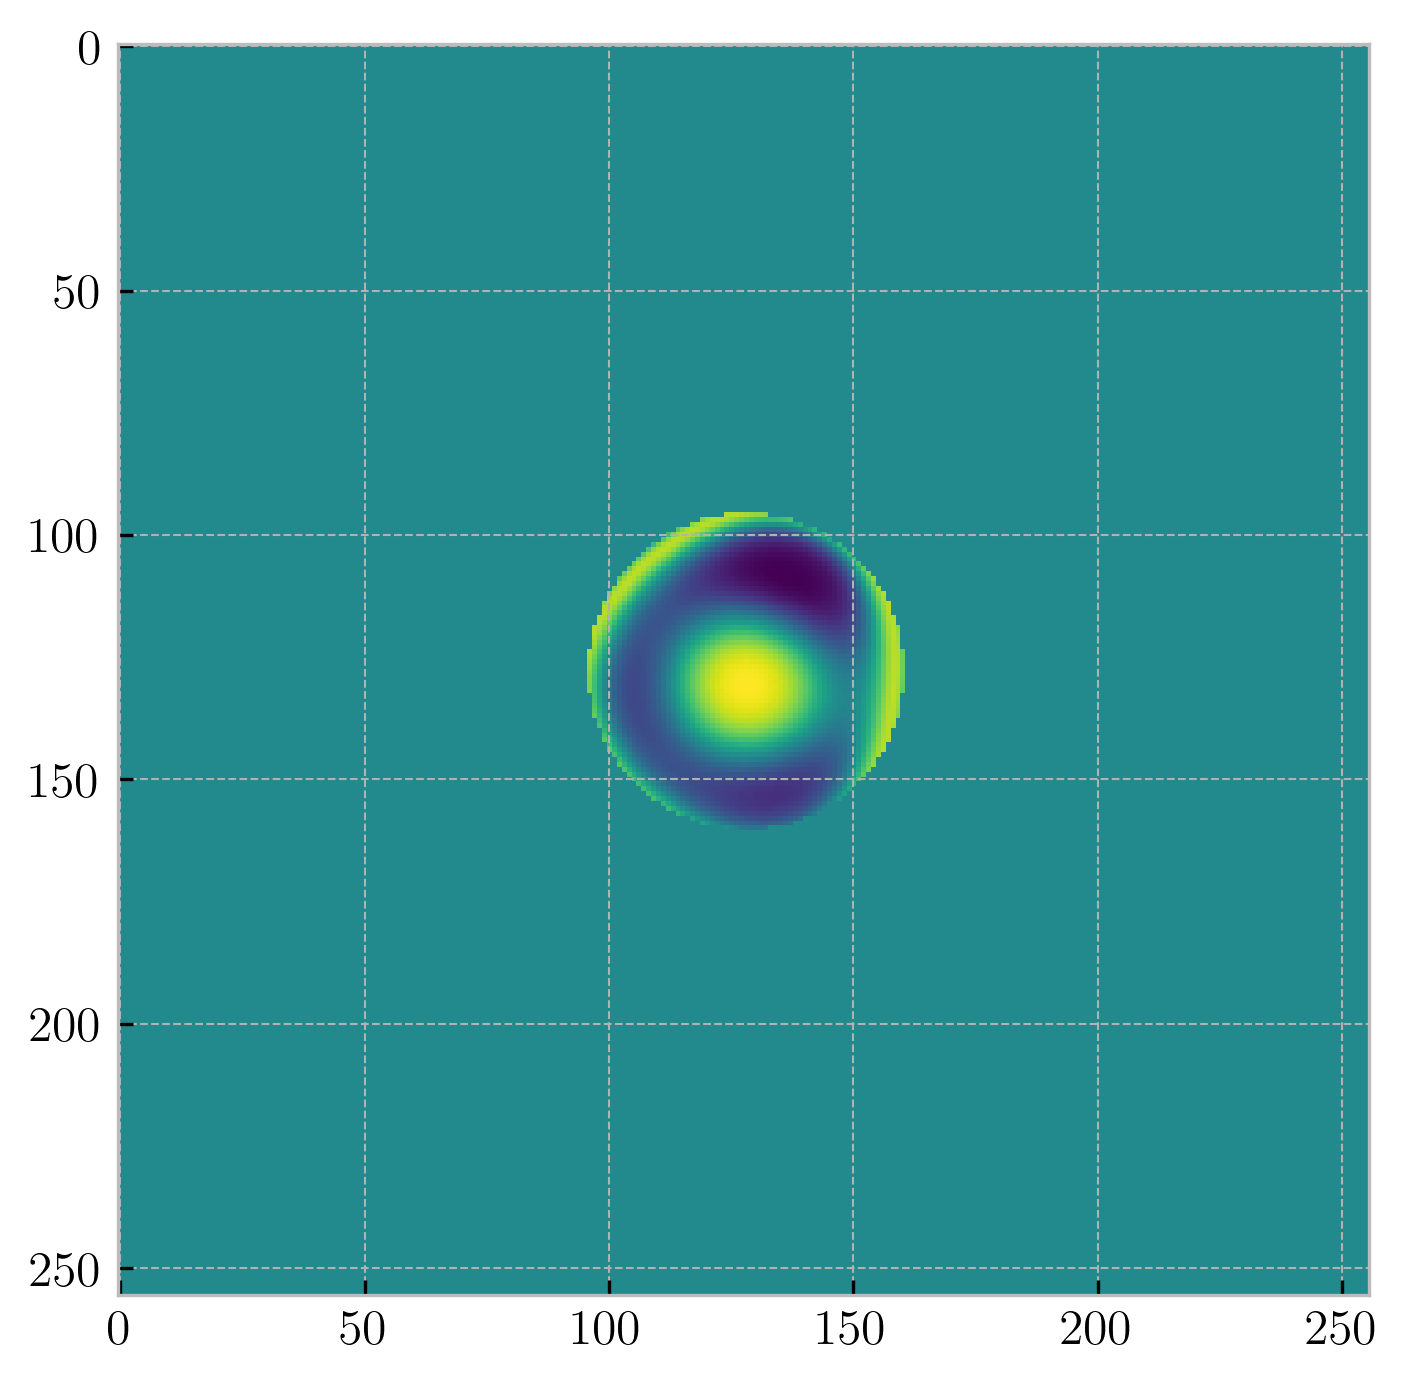

In [95]:
a = Aberration(modes_corrected, c_guess)
H = forward_H(microscope, a)
plt.imshow(np.imag(H))

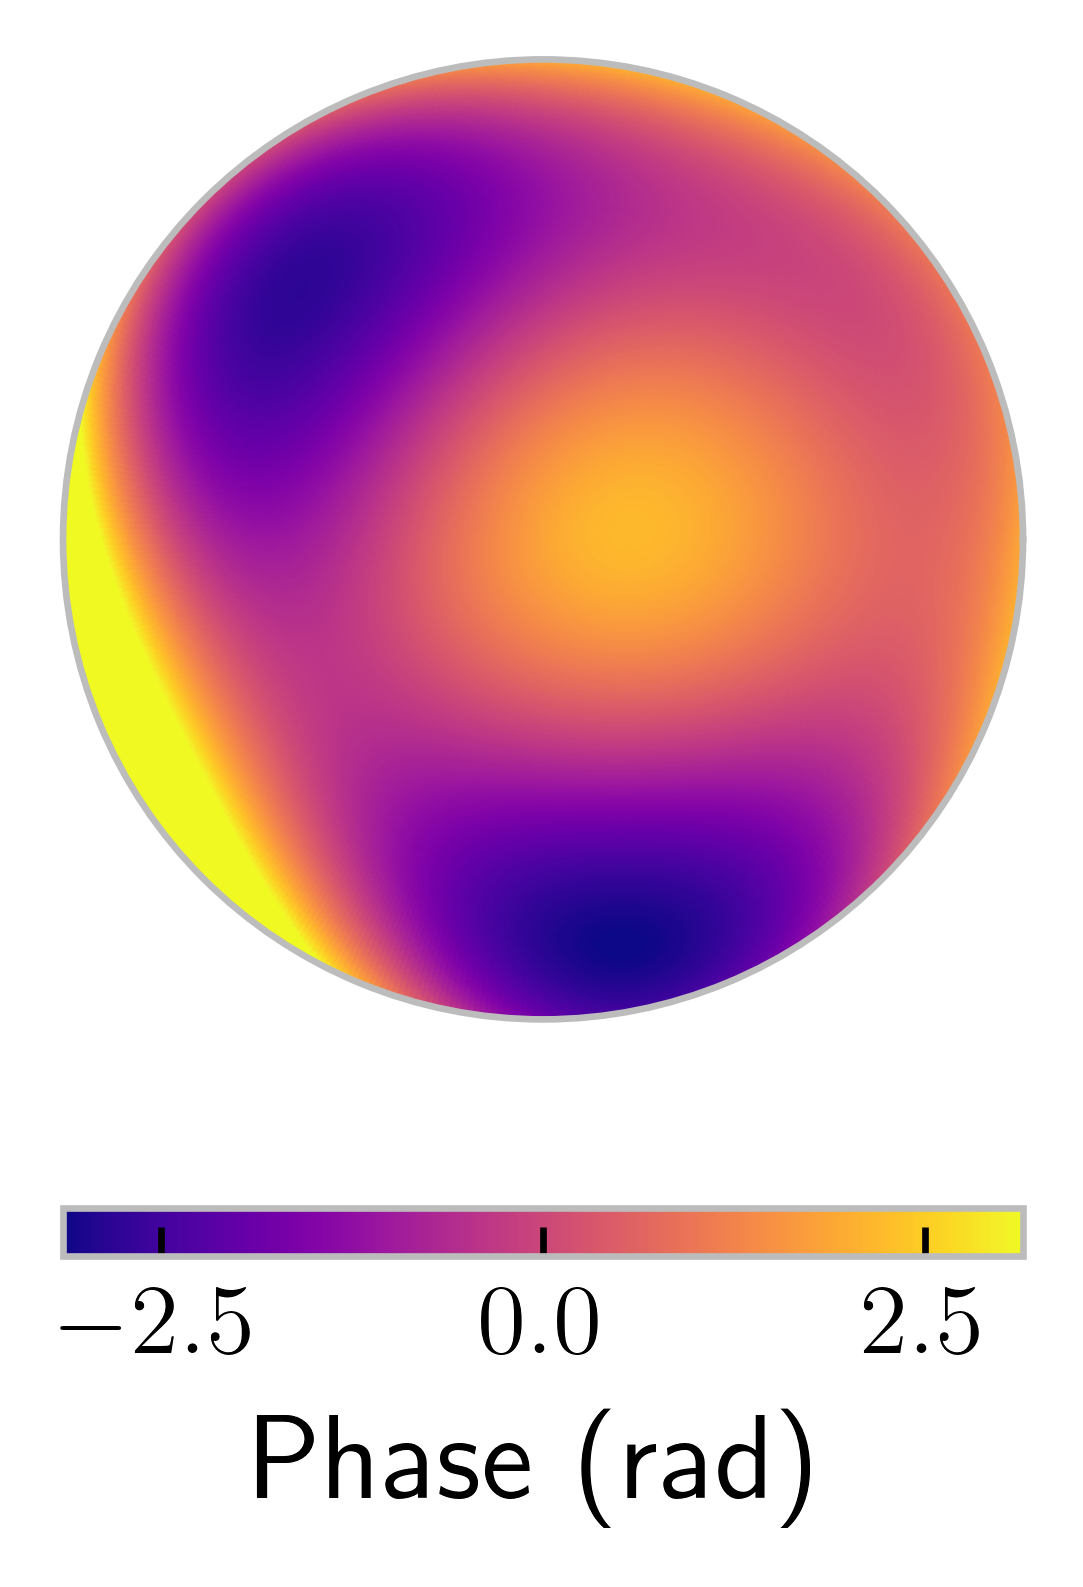

In [101]:
zernike_plot((Aberration(true_modes, c_guess)).construct_map(alpha), alpha)